In [1]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Emotion mapping for RAF-DB
emotion_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5,
    'surprise': 6
}

emotion_names = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

# Dataset path
train_path = "/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/train"
MAX_IMAGES_PER_CLASS = 200  # Changed from 500 to 200

print(f"Emotion Classes: {len(emotion_names)}")
print(f"Max images per emotion: {MAX_IMAGES_PER_CLASS}")

Emotion Classes: 7
Max images per emotion: 200


### 3. Load Data from RAF-DB Dataset

In [3]:
data = []
labels = []

for emotion_folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, emotion_folder)
    
    if not os.path.isdir(folder_path):
        continue
    
    if emotion_folder not in emotion_map:
        continue
    
    label = emotion_map[emotion_folder]
    image_list = os.listdir(folder_path)
    
    # Select random images up to MAX_IMAGES_PER_CLASS
    selected_images = random.sample(
        image_list,
        min(MAX_IMAGES_PER_CLASS, len(image_list))
    )
    
    for img_name in tqdm(selected_images, desc=emotion_folder):
        img_path = os.path.join(folder_path, img_name)
        
        try:
            # Read image in grayscale
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            # Resize to 128x128
            img = cv2.resize(img, (128, 128))
            
            data.append(img)
            labels.append(label)
        
        except Exception as e:
            print(f"Error loading {img_path}: {str(e)}")
            pass

# Convert to numpy arrays
data = np.array(data)
labels = np.array(labels)

print("\n" + "="*50)
print("Dataset Loading Complete")
print("="*50)
print(f"Data Shape: {data.shape}")
print(f"Labels Shape: {labels.shape}")
print(f"Data Type: {data.dtype}")
print(f"Data Range: [{data.min()}, {data.max()}]")

happy: 100%|██████████| 200/200 [00:00<00:00, 307.05it/s]


Dataset Loading Complete
Data Shape: (1400, 128, 128)
Labels Shape: (1400,)
Data Type: uint8
Data Range: [0, 255]


### 4. Verify Class Distribution


Class Distribution:
Total Images: 1400
Total Classes: 7

Angry       :  200 images
Disgust     :  200 images
Fear        :  200 images
Happy       :  200 images
Neutral     :  200 images
Sad         :  200 images
Surprise    :  200 images


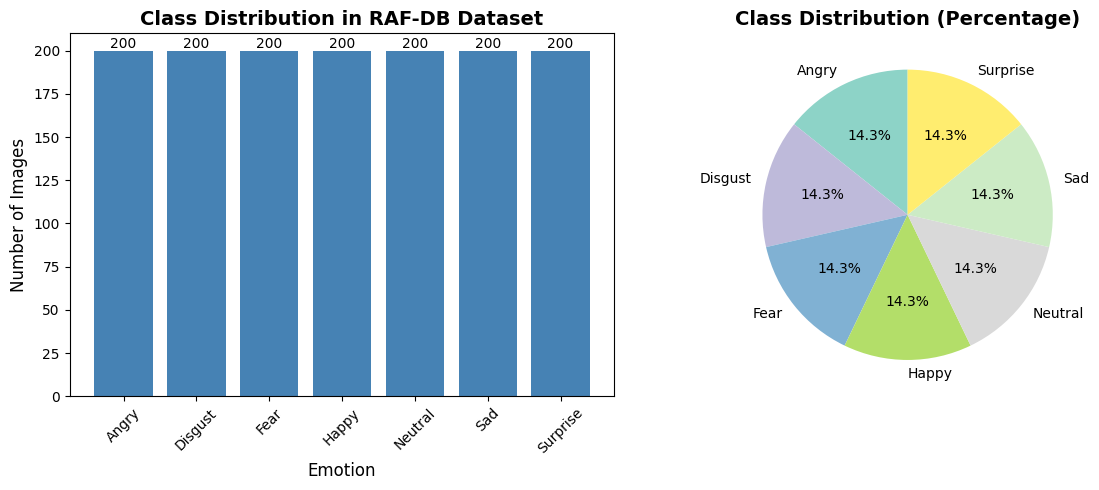

In [4]:
print("\nClass Distribution:")
print("="*50)
print(f"Total Images: {len(data)}")
print(f"Total Classes: {len(emotion_names)}")
print()

class_counts = {}
for i, emotion in enumerate(emotion_names):
    count = (labels == i).sum()
    class_counts[emotion] = count
    print(f"{emotion:12}: {count:4} images")

print("="*50)

# Visualize class distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution in RAF-DB Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

# Pie chart
plt.subplot(1, 2, 2)
colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_names)))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Data Preprocessing

In [5]:
# Normalize pixel values to 0-1 range
data = data.astype('float32') / 255.0

# Reshape data to add channel dimension (for CNN)
data = data.reshape(data.shape[0], data.shape[1], data.shape[2], 1)

print(f"Preprocessed Data Shape: {data.shape}")
print(f"Data normalized to range: [{data.min()}, {data.max()}]")

# One-hot encode labels
labels_categorical = keras.utils.to_categorical(labels, num_classes=len(emotion_names))
print(f"One-hot encoded labels shape: {labels_categorical.shape}")

Preprocessed Data Shape: (1400, 128, 128, 1)
Data normalized to range: [0.0, 1.0]
One-hot encoded labels shape: (1400, 7)


### 6. Split Data into Train and Test Sets

In [6]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels_categorical,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Further split train into train and validation: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train.argmax(axis=1)
)

print("\nData Split:")
print("="*50)
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/data.shape[0]*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/data.shape[0]*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/data.shape[0]*100:.1f}%)")
print("="*50)


Data Split:
Training set size: 896 (64.0%)
Validation set size: 224 (16.0%)
Test set size: 280 (20.0%)


### 7. Visualize Sample Images

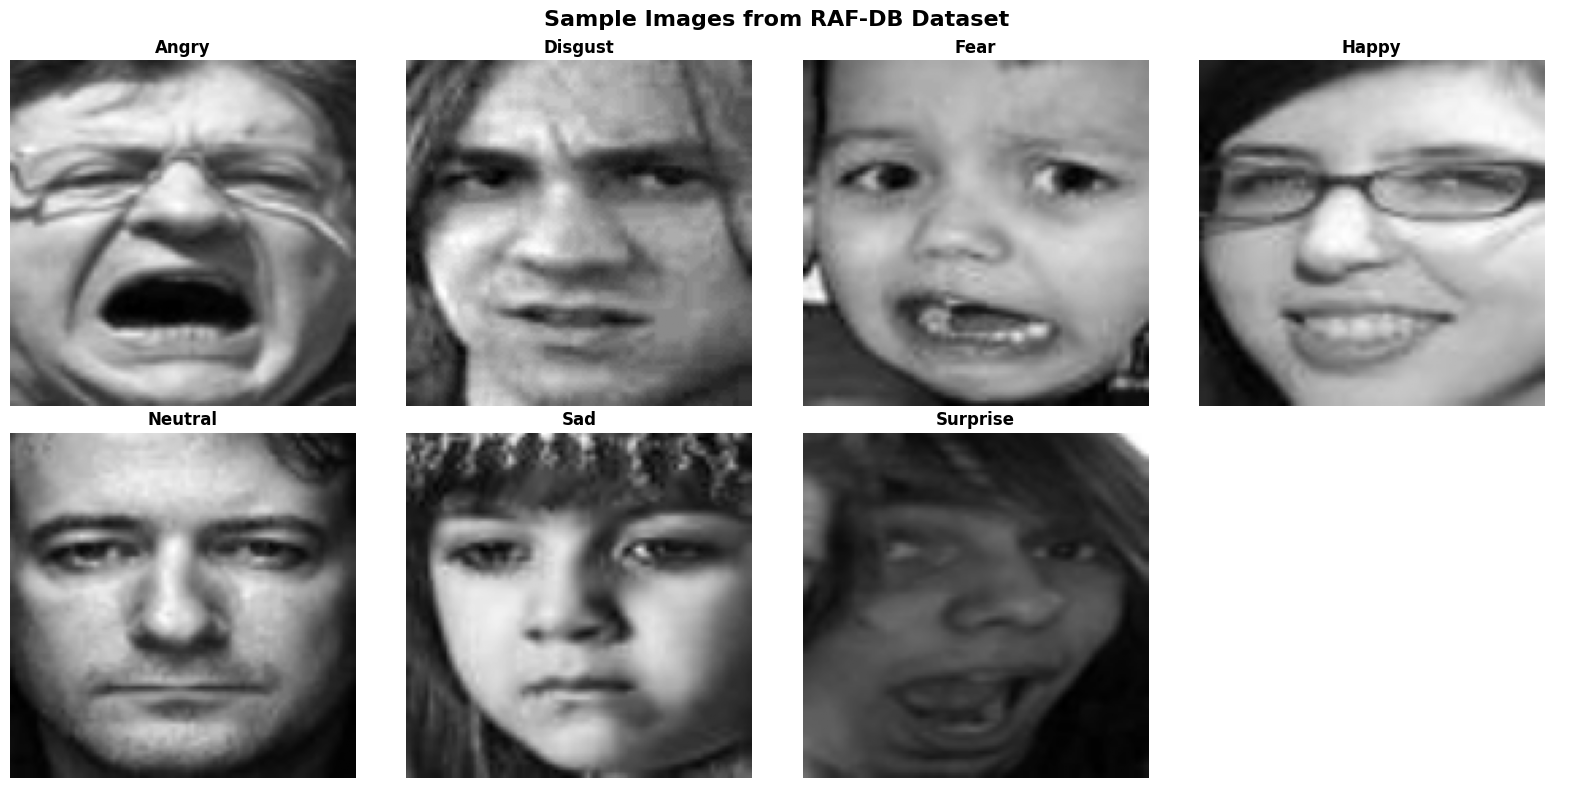

In [7]:
# Display sample images from each emotion
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Images from RAF-DB Dataset', fontsize=16, fontweight='bold')

for i in range(7):
    row = i // 4
    col = i % 4
    
    # Find a sample image of this emotion from training set
    emotion_indices = np.where(y_train[:, i] == 1)[0]
    if len(emotion_indices) > 0:
        sample_idx = emotion_indices[0]
        axes[row, col].imshow(X_train[sample_idx].reshape(128, 128), cmap='gray')
        axes[row, col].set_title(emotion_names[i], fontsize=12, fontweight='bold')
        axes[row, col].axis('off')

# Hide the last subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

### 8. Build CNN Model

In [8]:
# Build CNN Model
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # Output layer
    layers.Dense(len(emotion_names), activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print(model.summary())

I0000 00:00:1789640189.980533      21 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789640189.983709      21 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,700,839 (37.01 MB)

 Trainable params: 9,697,383 (36.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

None


In [9]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("Callbacks configured:")
print("- Early Stopping (patience=15)")
print("- Learning Rate Reduction (factor=0.5, patience=5)")

Callbacks configured:
- Early Stopping (patience=15)
- Learning Rate Reduction (factor=0.5, patience=5)


### 10. Train Model

In [10]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

Epoch 1/100


2026-09-17 10:16:44.792467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 10:16:44.945910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 10:16:46.398383: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 10:16:46.705368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/28 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.1875 - loss: 3.2613  

I0000 00:00:1789640217.193658      73 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.2042 - loss: 2.9161 - val_accuracy: 0.1429 - val_loss: 2.1223 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.2243 - loss: 2.4985 - val_accuracy: 0.1429 - val_loss: 2.7023 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.2556 - loss: 2.4522 - val_accuracy: 0.1429 - val_loss: 2.4887 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.2790 - loss: 2.2066 - val_accuracy: 0.1429 - val_loss: 2.1634 - learning_rate: 0.0010
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.3147 - loss: 2.0765 - val_accuracy: 0.1429 - val_loss: 2.5481 - learning_rate: 0.0010
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3108 - loss: 2.0510
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.3315 - loss: 1.9441 - val_accuracy

### 11. Plot Training History

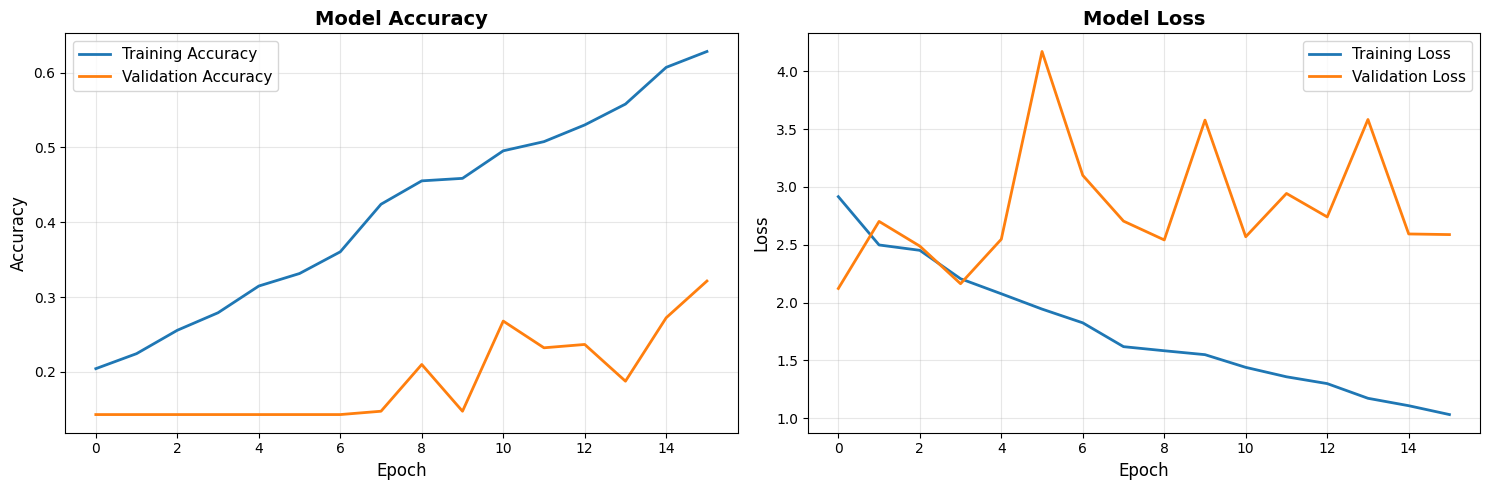

Best validation accuracy: 0.3214
Best validation loss: 2.1223


In [11]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")

### 12. Make Predictions on Test Set

In [12]:
# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_test_true.shape}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step
Predictions shape: (280,)
True labels shape: (280,)


### 13. Evaluation Metrics

In [13]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test_true, y_pred)
precision = precision_score(y_test_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*60)
print("EVALUATION METRICS ON TEST SET")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*60)

# Per-class metrics
print("\nPer-Class Metrics:")
print("-"*60)
for i, emotion in enumerate(emotion_names):
    class_mask = y_test_true == i
    if class_mask.sum() > 0:
        class_acc = accuracy_score(y_test_true[class_mask], y_pred[class_mask])
        class_precision = precision_score(y_test_true[class_mask], y_pred[class_mask], average='weighted', zero_division=0)
        class_recall = recall_score(y_test_true[class_mask], y_pred[class_mask], average='weighted', zero_division=0)
        class_f1 = f1_score(y_test_true[class_mask], y_pred[class_mask], average='weighted', zero_division=0)
        print(f"{emotion:12} | Acc: {class_acc:.4f} | Prec: {class_precision:.4f} | Rec: {class_recall:.4f} | F1: {class_f1:.4f}")
print("-"*60)


EVALUATION METRICS ON TEST SET
Accuracy:  0.1429 (14.29%)
Precision: 0.0204
Recall:    0.1429
F1-Score:  0.0357

Per-Class Metrics:
------------------------------------------------------------
Angry        | Acc: 0.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Disgust      | Acc: 0.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Fear         | Acc: 0.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Happy        | Acc: 0.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Neutral      | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
Sad          | Acc: 0.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Surprise     | Acc: 0.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
------------------------------------------------------------


### 14. Classification Report

In [14]:
# Detailed classification report
print("\nDetailed Classification Report:")
print("="*80)
print(classification_report(
    y_test_true,
    y_pred,
    target_names=emotion_names,
    digits=4
))


Detailed Classification Report:
              precision    recall  f1-score   support

       Angry     0.0000    0.0000    0.0000        40
     Disgust     0.0000    0.0000    0.0000        40
        Fear     0.0000    0.0000    0.0000        40
       Happy     0.0000    0.0000    0.0000        40
     Neutral     0.1429    1.0000    0.2500        40
         Sad     0.0000    0.0000    0.0000        40
    Surprise     0.0000    0.0000    0.0000        40

    accuracy                         0.1429       280
   macro avg     0.0204    0.1429    0.0357       280
weighted avg     0.0204    0.1429    0.0357       280



### 15. Confusion Matrix

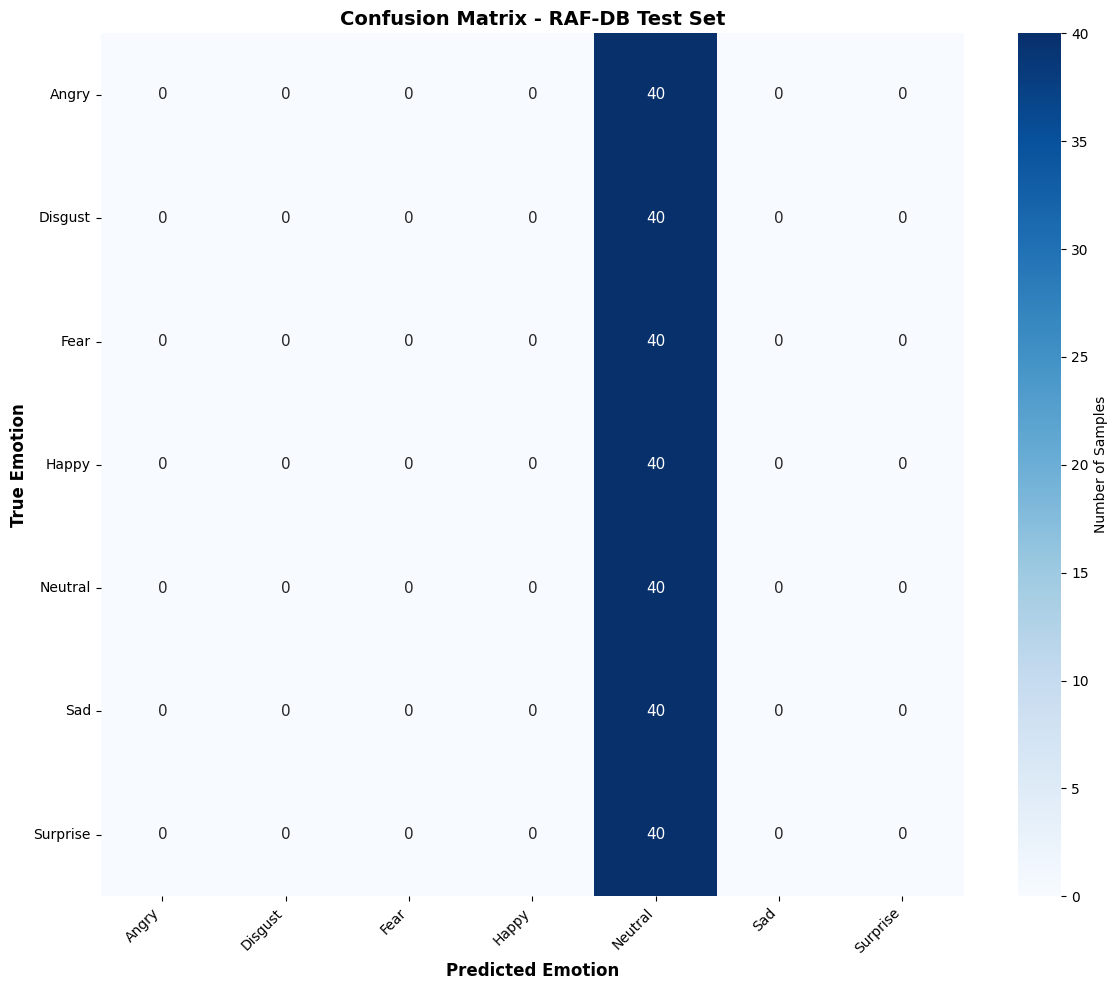


Total Test Samples: 280
Correct Predictions: 40
Incorrect Predictions: 240


In [15]:
# Calculate confusion matrix
cm = confusion_matrix(y_test_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cbar_kws={'label': 'Number of Samples'},
    annot_kws={'size': 11}
)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - RAF-DB Test Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nTotal Test Samples: {len(y_test_true)}")
print(f"Correct Predictions: {(y_pred == y_test_true).sum()}")
print(f"Incorrect Predictions: {(y_pred != y_test_true).sum()}")

### 16. Normalized Confusion Matrix

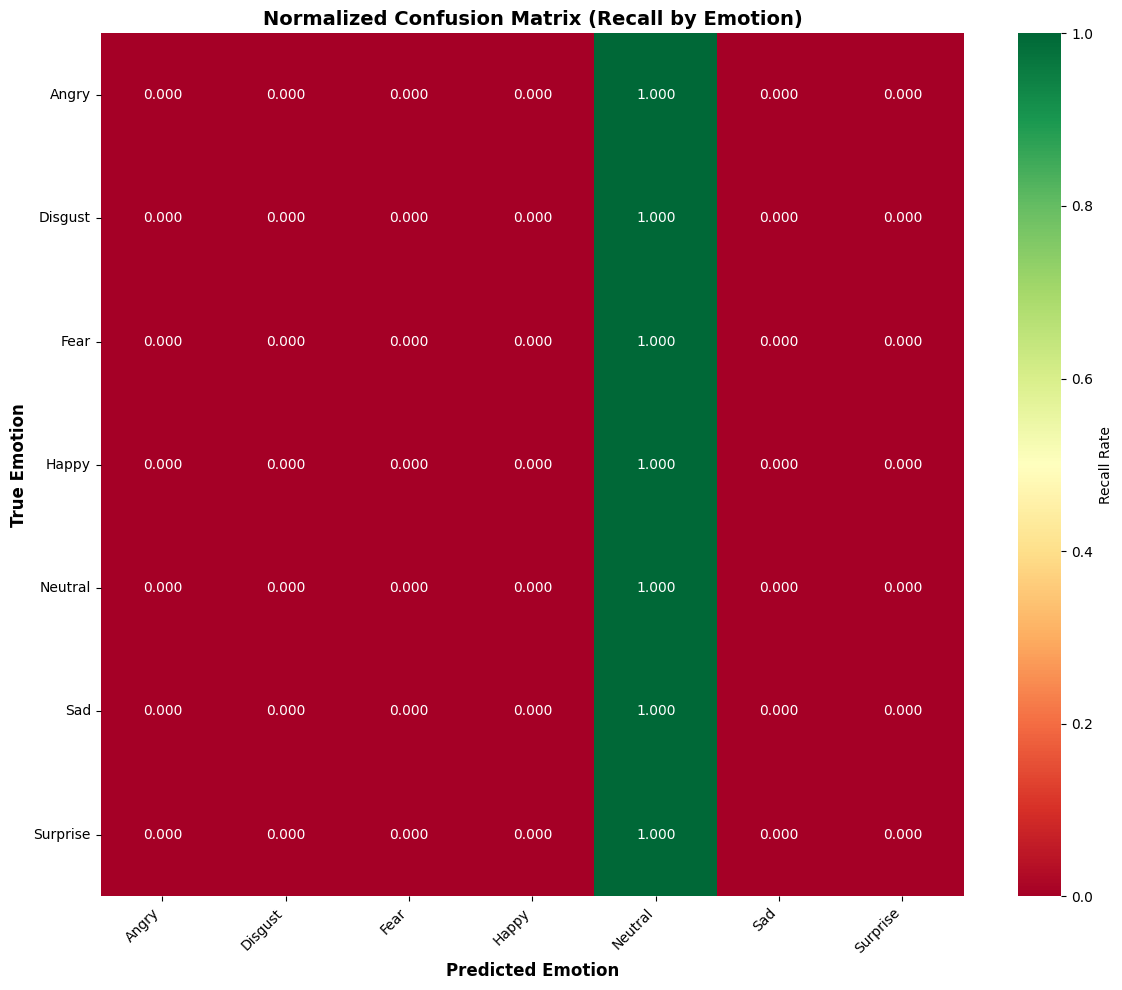

In [16]:
# Normalized confusion matrix (by true label)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cbar_kws={'label': 'Recall Rate'},
    annot_kws={'size': 10},
    vmin=0, vmax=1
)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix (Recall by Emotion)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 17. Per-Emotion Performance Visualization

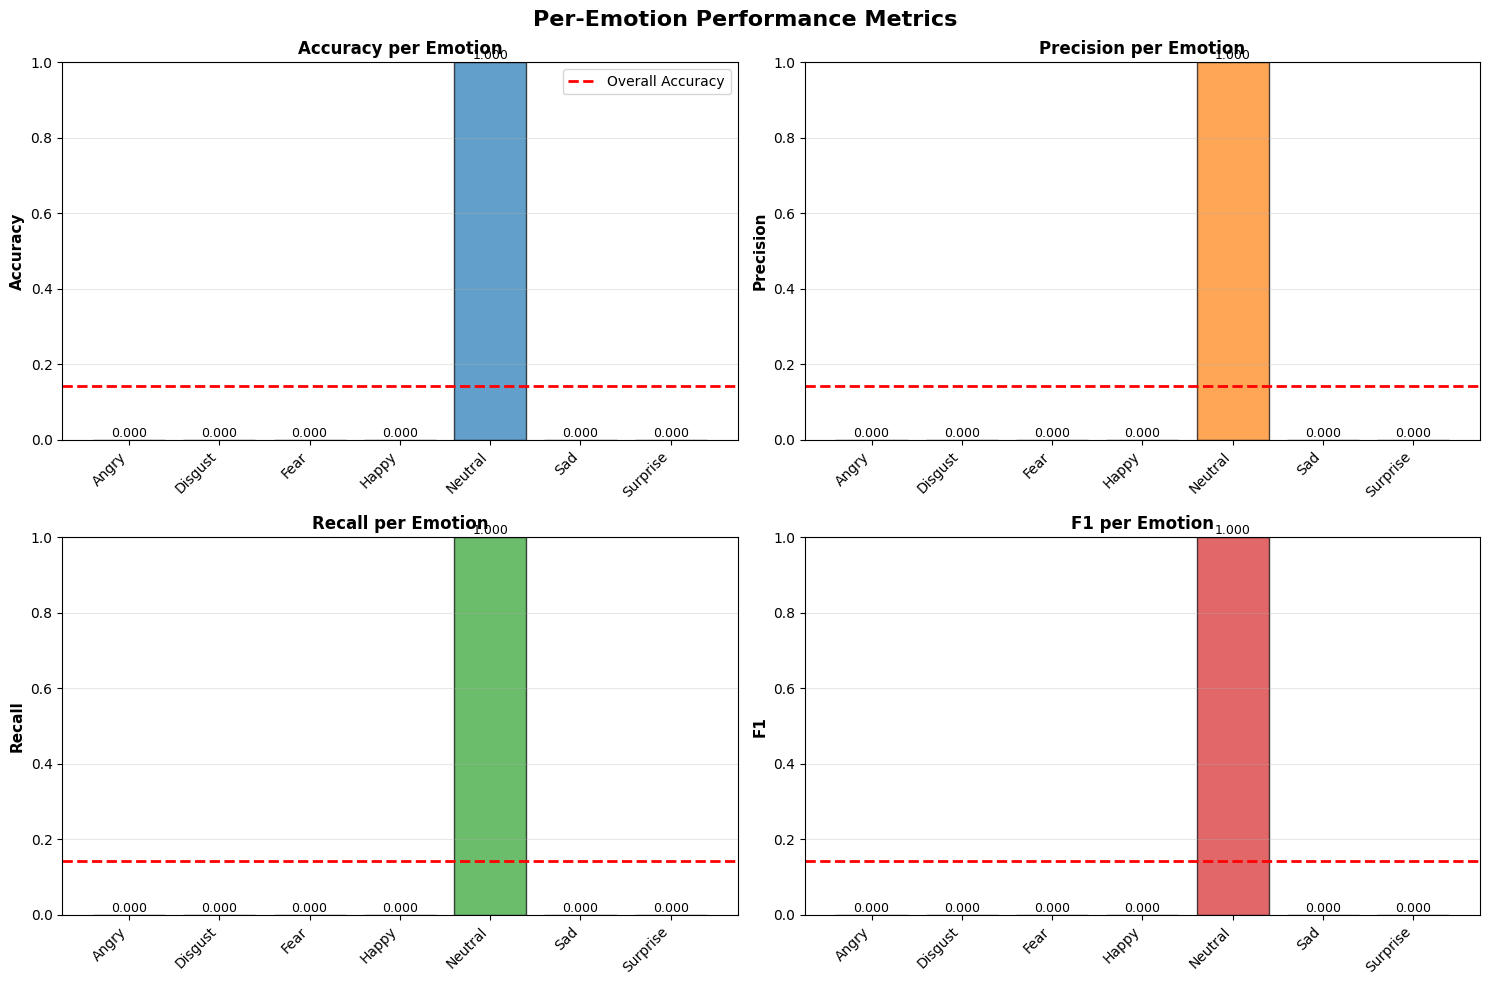

In [17]:
# Calculate per-emotion metrics
per_emotion_metrics = {}

for i, emotion in enumerate(emotion_names):
    class_mask = y_test_true == i
    if class_mask.sum() > 0:
        class_acc = accuracy_score(y_test_true[class_mask], y_pred[class_mask])
        class_precision = precision_score(y_test_true[class_mask], y_pred[class_mask], average='weighted', zero_division=0)
        class_recall = recall_score(y_test_true[class_mask], y_pred[class_mask], average='weighted', zero_division=0)
        class_f1 = f1_score(y_test_true[class_mask], y_pred[class_mask], average='weighted', zero_division=0)
        per_emotion_metrics[emotion] = {
            'Accuracy': class_acc,
            'Precision': class_precision,
            'Recall': class_recall,
            'F1': class_f1
        }

# Visualize per-emotion performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Per-Emotion Performance Metrics', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = [per_emotion_metrics[emotion][metric] for emotion in emotion_names]
    bars = ax.bar(emotion_names, values, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} per Emotion', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=accuracy, color='red', linestyle='--', linewidth=2, label='Overall Accuracy')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)
    
    ax.legend() if idx == 0 else None
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 18. Prediction Examples

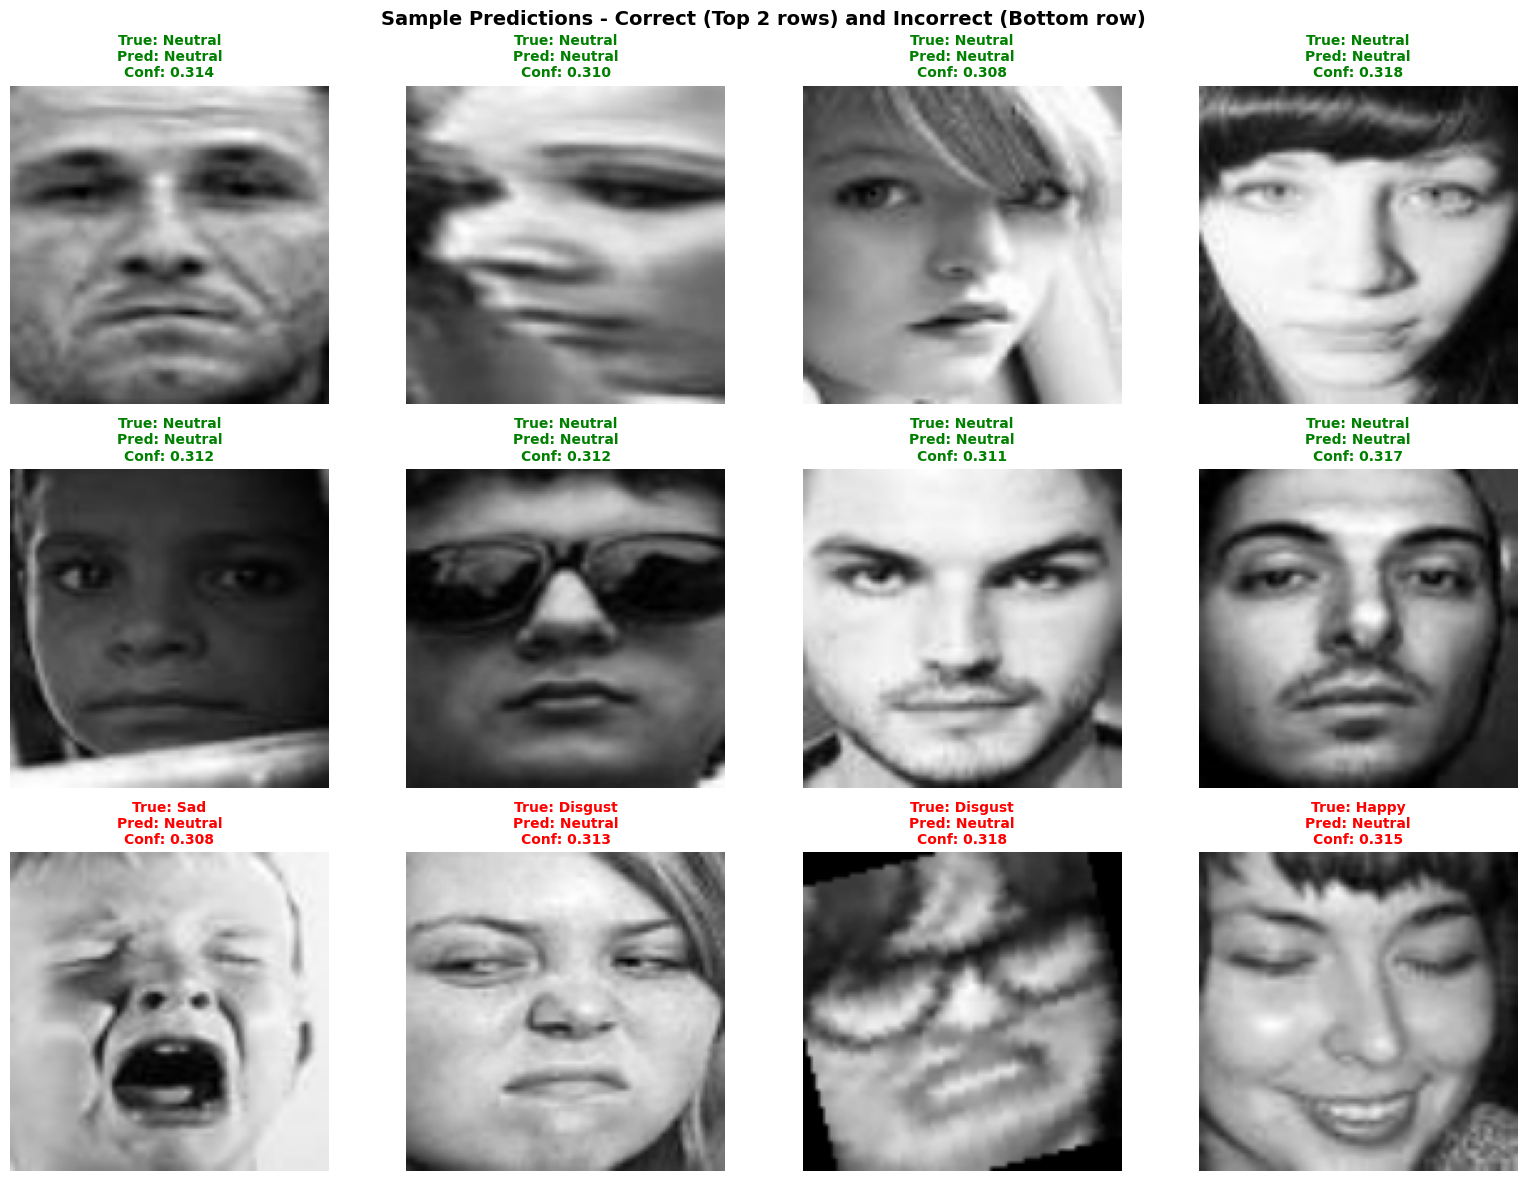


Total Correct Predictions: 40 / 280
Total Incorrect Predictions: 240 / 280


In [18]:
# Show some correct and incorrect predictions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Sample Predictions - Correct (Top 2 rows) and Incorrect (Bottom row)', fontsize=14, fontweight='bold')

# Get correct predictions
correct_mask = y_pred == y_test_true
correct_indices = np.where(correct_mask)[0]

# Get incorrect predictions
incorrect_mask = y_pred != y_test_true
incorrect_indices = np.where(incorrect_mask)[0]

# Show correct predictions
for i in range(8):
    ax = axes[i // 4, i % 4]
    if i < len(correct_indices):
        idx = correct_indices[i]
        ax.imshow(X_test[idx].reshape(128, 128), cmap='gray')
        true_emotion = emotion_names[y_test_true[idx]]
        pred_emotion = emotion_names[y_pred[idx]]
        confidence = y_pred_probs[idx].max()
        ax.set_title(f'True: {true_emotion}\nPred: {pred_emotion}\nConf: {confidence:.3f}',
                    fontsize=10, fontweight='bold', color='green')
        ax.axis('off')

# Show incorrect predictions
for i in range(4):
    ax = axes[2, i]
    if i < len(incorrect_indices):
        idx = incorrect_indices[i]
        ax.imshow(X_test[idx].reshape(128, 128), cmap='gray')
        true_emotion = emotion_names[y_test_true[idx]]
        pred_emotion = emotion_names[y_pred[idx]]
        confidence = y_pred_probs[idx].max()
        ax.set_title(f'True: {true_emotion}\nPred: {pred_emotion}\nConf: {confidence:.3f}',
                    fontsize=10, fontweight='bold', color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nTotal Correct Predictions: {correct_mask.sum()} / {len(y_test_true)}")
print(f"Total Incorrect Predictions: {incorrect_mask.sum()} / {len(y_test_true)}")

### 19. Save Model and Summary

In [19]:
# Save the model
model.save('raf_db_emotion_model.h5')
print("Model saved as 'raf_db_emotion_model.h5'")

# Create a summary
summary_text = f"""
RAF-DB FACIAL EXPRESSION RECOGNITION - MODEL SUMMARY
{'='*70}

DATASET INFORMATION:
- Dataset: RAF-DB (Real-world Affective Faces Database)
- Total Images: {len(data)}
- Images per Emotion: 200
- Emotions: {len(emotion_names)} ({', '.join(emotion_names)})
- Image Size: 128x128 pixels (grayscale)

DATA SPLIT:
- Training: {X_train.shape[0]} samples ({X_train.shape[0]/data.shape[0]*100:.1f}%)
- Validation: {X_val.shape[0]} samples ({X_val.shape[0]/data.shape[0]*100:.1f}%)
- Test: {X_test.shape[0]} samples ({X_test.shape[0]/data.shape[0]*100:.1f}%)

MODEL ARCHITECTURE:
- Type: Convolutional Neural Network (CNN)
- Input Shape: (128, 128, 1)
- Output Classes: {len(emotion_names)}
- Optimizer: Adam (lr=0.001)
- Loss Function: Categorical Crossentropy
- Epochs Trained: {len(history.history['loss'])}

PERFORMANCE METRICS:
- Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)
- Precision: {precision:.4f}
- Recall: {recall:.4f}
- F1-Score: {f1:.4f}

BEST VALIDATION METRICS:
- Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}
- Best Validation Loss: {min(history.history['val_loss']):.4f}

PREDICTIONS:
- Correct Predictions: {(y_pred == y_test_true).sum()} / {len(y_test_true)}
- Incorrect Predictions: {(y_pred != y_test_true).sum()} / {len(y_test_true)}

{'='*70}
"""

print(summary_text)

# Save summary to file
with open('raf_db_model_summary.txt', 'w') as f:
    f.write(summary_text)
print("\nSummary saved as 'raf_db_model_summary.txt'")

Model saved as 'raf_db_emotion_model.h5'

RAF-DB FACIAL EXPRESSION RECOGNITION - MODEL SUMMARY

DATASET INFORMATION:
- Dataset: RAF-DB (Real-world Affective Faces Database)
- Total Images: 1400
- Images per Emotion: 200
- Emotions: 7 (Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise)
- Image Size: 128x128 pixels (grayscale)

DATA SPLIT:
- Training: 896 samples (64.0%)
- Validation: 224 samples (16.0%)
- Test: 280 samples (20.0%)

MODEL ARCHITECTURE:
- Type: Convolutional Neural Network (CNN)
- Input Shape: (128, 128, 1)
- Output Classes: 7
- Optimizer: Adam (lr=0.001)
- Loss Function: Categorical Crossentropy
- Epochs Trained: 16

PERFORMANCE METRICS:
- Test Accuracy: 0.1429 (14.29%)
- Precision: 0.0204
- Recall: 0.1429
- F1-Score: 0.0357

BEST VALIDATION METRICS:
- Best Validation Accuracy: 0.3214
- Best Validation Loss: 2.1223

PREDICTIONS:
- Correct Predictions: 40 / 280
- Incorrect Predictions: 240 / 280



Summary saved as 'raf_db_model_summary.txt'


### 20. Confidence Distribution Analysis

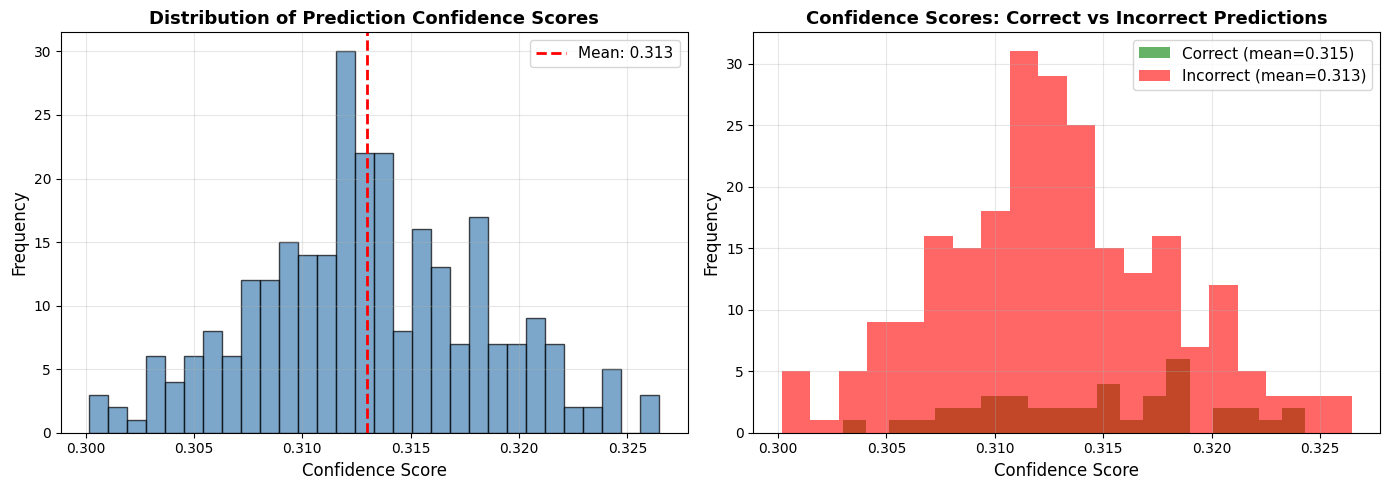


Confidence Score Statistics:
Mean Confidence: 0.3130
Median Confidence: 0.3128
Std Deviation: 0.0053
Min Confidence: 0.3002
Max Confidence: 0.3265

Correct Predictions Avg Confidence: 0.3146
Incorrect Predictions Avg Confidence: 0.3127


In [20]:
# Analyze prediction confidence
confidence_scores = np.max(y_pred_probs, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence scores
axes[0].hist(confidence_scores, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(confidence_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {confidence_scores.mean():.3f}')
axes[0].set_xlabel('Confidence Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Confidence Scores', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Confidence vs Accuracy
correct_confidence = confidence_scores[y_pred == y_test_true]
incorrect_confidence = confidence_scores[y_pred != y_test_true]

axes[1].hist(correct_confidence, bins=20, alpha=0.6, label=f'Correct (mean={correct_confidence.mean():.3f})', color='green')
axes[1].hist(incorrect_confidence, bins=20, alpha=0.6, label=f'Incorrect (mean={incorrect_confidence.mean():.3f})', color='red')
axes[1].set_xlabel('Confidence Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Confidence Scores: Correct vs Incorrect Predictions', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConfidence Score Statistics:")
print(f"Mean Confidence: {confidence_scores.mean():.4f}")
print(f"Median Confidence: {np.median(confidence_scores):.4f}")
print(f"Std Deviation: {confidence_scores.std():.4f}")
print(f"Min Confidence: {confidence_scores.min():.4f}")
print(f"Max Confidence: {confidence_scores.max():.4f}")
print(f"\nCorrect Predictions Avg Confidence: {correct_confidence.mean():.4f}")
print(f"Incorrect Predictions Avg Confidence: {incorrect_confidence.mean():.4f}")